Episode 01 | Total reward: -198.0
Episode 02 | Total reward: -182.0
Episode 03 | Total reward: 75.0
Episode 04 | Total reward: 79.0
Episode 05 | Total reward: -355.0
Episode 06 | Total reward: 95.0
Episode 07 | Total reward: 47.0
Episode 08 | Total reward: 95.0
Episode 09 | Total reward: 95.0
Episode 10 | Total reward: 95.0
Episode 11 | Total reward: 95.0
Episode 12 | Total reward: -32.0
Episode 13 | Total reward: 95.0
Episode 14 | Total reward: 75.0
Episode 15 | Total reward: -355.0
Episode 16 | Total reward: 75.0
Episode 17 | Total reward: 95.0
Episode 18 | Total reward: 67.0
Episode 19 | Total reward: 91.0
Episode 20 | Total reward: -17.0


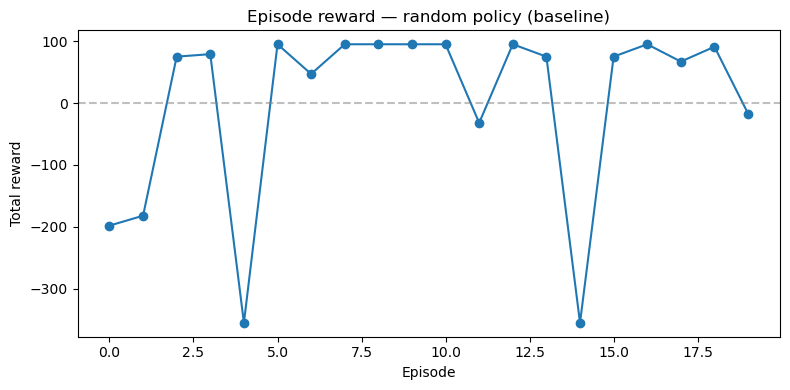

In [3]:
import gymnasium
import vizdoom as vzd
from vizdoom import gymnasium_wrapper  # noqa
import matplotlib.pyplot as plt
import numpy as np
''' This code plots the rewards using a headless configuration which can be used to '''

# Recreate with render_mode=None 
env = gymnasium.make(
    "VizdoomBasic-v1",
    render_mode=None,       #no display needed 
    frame_skip=4,
    screen_resolution=vzd.ScreenResolution.RES_320X240,
)

# Track and plot rewards
episode_rewards = []

termination_thresh = 100 # arbitrary
no_of_episodes = 20
# Create the matrix filled with the low rew values
rew_mat = np.full((no_of_episodes, termination_thresh),np.nan)

# Rendering rollouts for N episodes
for ep in range(no_of_episodes):
    obs, info = env.reset(seed=16)
    total = 0
    attempt_number = 0
    done = False
    while not done:
        # random actions via action_space.sample()
        obs, rew, terminated, truncated, info = env.step(env.action_space.sample())
        rew_mat[ep, attempt_number] = rew
        attempt_number = attempt_number + 1
        total += rew
        done = terminated or truncated or attempt_number>= termination_thresh
    episode_rewards.append(total)
    print(f"Episode {ep+1:02d} | Total reward: {total:.1f}")

env.close()

# Plot
plt.figure(figsize=(8, 4))
plt.plot(episode_rewards, marker='o')
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.title("Episode reward — random policy (baseline)")
plt.xlabel("Episode")
plt.ylabel("Total reward")
plt.tight_layout()
plt.show()
